# Математическая статистика для анализа больших данных.
## Задание 10
### Стратификация

Выполненную работу нужно отправить телеграм-боту  `@stats_bd_bot`
* Дедлайн см. в телеграм-боте. После дедлайна работы не принимаются кроме случаев наличия уважительной причины.
* По практическим задачам прислать нужно ноутбук в формате `ipynb`.
* Решения, размещенные на каких-либо интернет-ресурсах не принимаются. Кроме того, публикация решения в открытом доступе может быть приравнена к предоставлении возможности списать.
* Не забывайте делать пояснения и выводы.
* Решение теоретических задач можете записывать в markdown с помощью TeX, присылать в виде фотографий или вшивать в ноутбук через Insert Image (убеждайтесь, что картинка сохраняется при перемещении ноутбука в другое место)

---

### Задача 1 (2 балла)

Пусть в общей совокупности данных имеется $K$ страт, причем вес страты $k \in \{1, ..., K\}$ равен $w_k$, где $w_1+...+w_K=1$. Пусть также выборка размера $n$ выбрана случайно, то есть вероятность выбрать элемент из страты $k$ равна $w_k$.

Посчитайте $\mathsf{E} \frac{1}{n_k}$ с точностью до $o(1/n^2)$, где $n_k$ &mdash; количество элементов выборки из страты $k$.

*Указание.* Разложите по Тейлору функцию $f(x)=1/x$ в точке $x_0\not=0$.

У нас есть страта $k$ с весом $w_k$ в общей совокупности, и выборка объема $n$, взятая случайным образом. Количество выбранных элементов из страты $k$ обозначается как $n_k$, и оно следует биномиальному распределению:

$$
n_k \sim \text{Binomial}(n, w_k)
$$

Цель — найти $E\left(\frac{1}{n_k}\right)$ с точностью до $o\left(\frac{1}{n^2}\right)$.

Математическое ожидание $n_k$ равно $E[n_k] = n w_k$, а дисперсия $Var[n_k] = n w_k (1 - w_k)$. Для вычислений понадобится второй центральный момент $\mu_2 = Var[n_k] = n w_k (1 - w_k)$ и третий центральный момент $\mu_3 = n w_k (1 - w_k)(1 - 2 w_k)$.

Рассмотрим функцию $\frac{1}{n_k}$. Поскольку $n_k$ принимает значения около своего математического ожидания $n w_k$, разложим функцию $\frac{1}{n_k}$ в ряд Тейлора вокруг точки $x_0 = n w_k$:

$$
\frac{1}{n_k} = \frac{1}{n w_k} \cdot \frac{1}{1 + \epsilon}, \quad \epsilon = \frac{n_k - n w_k}{n w_k}
$$

Разложение $\frac{1}{1 + \epsilon}$ в ряд Тейлора:

$$
\frac{1}{1 + \epsilon} = 1 - \epsilon + \epsilon^2 - \epsilon^3 + \dots
$$

Для точности до $o\left(\frac{1}{n^2}\right)$ достаточно учесть члены до $\epsilon^2$. Таким образом:

$$
\frac{1}{n_k} \approx \frac{1}{n w_k} (1 - \epsilon + \epsilon^2)
$$

Математическое ожидание $\epsilon$ равно $E[\epsilon] = 0$, а $E[\epsilon^2] = Var[\epsilon] = \frac{1 - w_k}{n w_k}$. Теперь можно найти $E\left(\frac{1}{n_k}\right)$:

$$
E\left(\frac{1}{n_k}\right) \approx \frac{1}{n w_k} \left(1 + E[\epsilon^2]\right)
$$


$$
E\left(\frac{1}{n_k}\right) \approx \frac{1}{n w_k} + \frac{1 - w_k}{n^2 w_k^3}
$$

Остаточные члены ($E[\epsilon^3]$) оказываются порядка $o\left(\frac{1}{n^2}\right)$, ими можно пренебречь. Таким образом, итоговое выражение с точностью до $o\left(\frac{1}{n^2}\right)$:

$$
E\left(\frac{1}{n_k}\right) = \frac{1}{n w_k} + \frac{1 - w_k}{n^2 w_k^3} + o\left(\frac{1}{n^2}\right)
$$


---
### Задача 2 (15 баллов)

Вам выдана часть информации о визитах пользователей на сайте Физтех.Статистики начиная с 2021 года по данным Яндекс.Метрики. Визит &mdash; последовательность действий пользователя на сайте, которая начинается на некоторой странице сайта, содержит в себе переходы по ссылкам (и другие действия), и заканчивается на какой-то, возможно, другой страницей сайта. Визит считается завершенным, если активность отсутствует в течение некоторого времени, обычно &mdash; 30 минут.

Описание полей доступно по <a href="https://yandex.ru/dev/metrika/doc/api2/logs/fields/visits.html">ссылке</a>.

Ознакомьтесь с данными, ответив на следующие вопросы.
1. Сколько всего визитов представлено в данных?
2. Когда совершены первый и последний визиты?
3. Постройте динамику количества визитов во времени по дням.
4. Сколько уникальных пользователей в данных?
5. Сколько в среднем один пользователь совершил визитов? Сколько максимально?
6. Постройте гистограмму глубины и продолжительности визитов.
7. Из каких стран больше пользователей?
8. Какие браузеры и операционные системы в топе?

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

try:
    import openpyxl
except ImportError:
    !pip install openpyxl

from scipy import stats

In [4]:
data = pd.read_excel('data_task10.xlsx', parse_dates=['ym:s:dateTimeUTC'])

Отдельно обратите внимание на поведение пользователей на исторических данных. Очевидно, что они как-то связанны с поведением студентов в течение года, в частности с началами и концами учебных семестров, еженедельными дедлайнами и т.д. для конкретики будем оценивать дисперсию в последующих пунктах с помощью данных за апрель прошлого года.

In [5]:
data.head()

,ym:s:dateTimeUTC,ym:s:clientID,ym:s:isNewUser,ym:s:startURL,ym:s:endURL,ym:s:pageViews,ym:s:visitDuration,ym:s:regionCountry,ym:s:operatingSystemRoot,ym:s:browser
0,2023-03-06 23:59:20,1666887221608793088,1,https://mipt-stats.gitlab.io/courses/python/07...,https://forms.yandex.ru/u/60290d5098f7287713f0...,6,121,United States,windows,chrome
1,2023-03-06 23:50:47,167791555242368000,0,https://miptstats.github.io/courses/ad_fivt.html,https://forms.yandex.ru/u/62001eb89ae318f2377d...,5,274,Russia,windows,chrome
2,2023-03-06 23:46:24,167813558512309408,1,https://mipt-stats.gitlab.io/courses/python/02...,https://mipt-stats.gitlab.io/courses/python/02...,1,16,Germany,windows,chrome
3,2023-03-06 23:43:41,1676653413443987968,0,https://forms.yandex.ru/u/62001eb89ae318f2377d...,https://miptstats.github.io/courses/ad_fivt/ta...,3,20,Russia,windows,chrome
4,2023-03-06 23:32:59,1675691855891792896,0,https://forms.yandex.ru/u/62001eb89ae318f2377d...,https://miptstats.github.io/courses/ad_fivt/ta...,4,25,Russia,gnu_linux,chrome


Сколько всего визитов представлено в данных?

In [6]:
print(data.shape[0])


181220


Когда совершены первый и последний визиты?

In [7]:
print(data['ym:s:dateTimeUTC'].min())
print(data['ym:s:dateTimeUTC'].max())


2021-01-01 02:33:44
2023-03-06 23:59:20


Постройте динамику количества визитов во времени по дням.

<Axes: xlabel='date'>

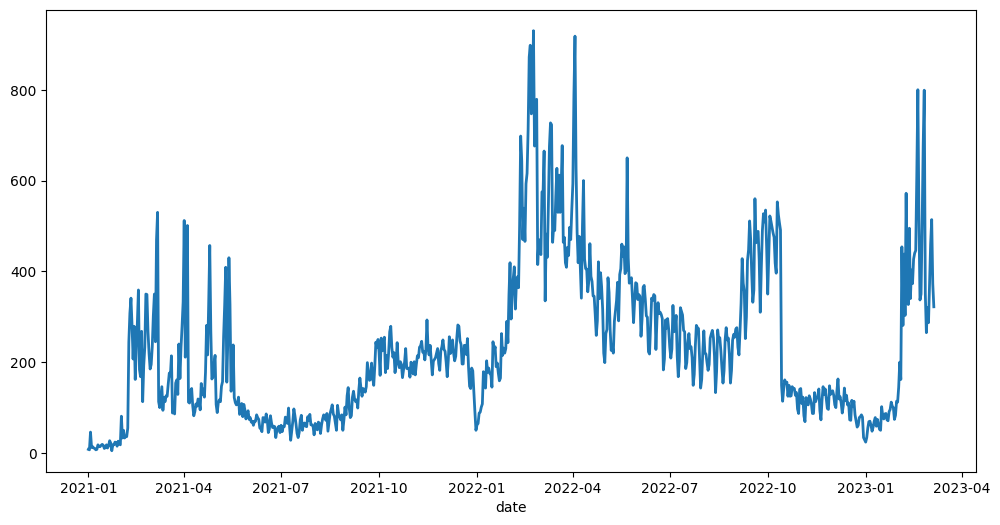

In [8]:
data['date'] = data['ym:s:dateTimeUTC'].dt.date
visits_per_day = data.groupby('date').size()
visits_per_day.plot(figsize=(12, 6), lw=2)

Сколько уникальных пользователей в данных?

In [9]:
data['ym:s:clientID'].nunique()


84820

Сколько в среднем один пользователь совершил визитов? Сколько максимально?

In [10]:
visits_per_user = data.groupby('ym:s:clientID').size()
visits_per_user.mean()
visits_per_user.max()


520

Постройте гистограмму глубины и продолжительности визитов.

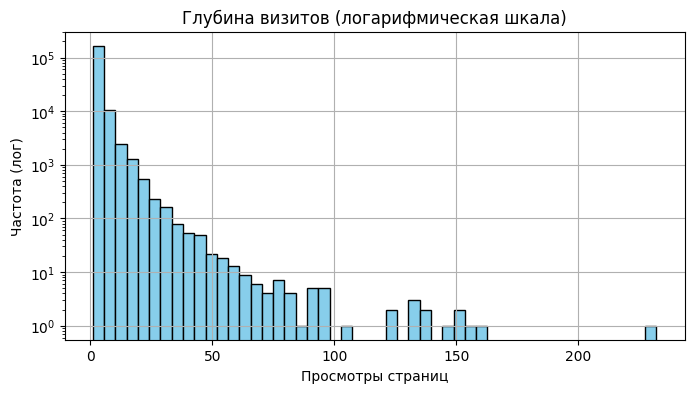

In [11]:
data['ym:s:pageViews'].hist(bins=50, figsize=(8, 4), color='skyblue', edgecolor='black', log=True)
plt.title('Глубина визитов (логарифмическая шкала)')
plt.xlabel('Просмотры страниц')
plt.ylabel('Частота (лог)')
plt.show()


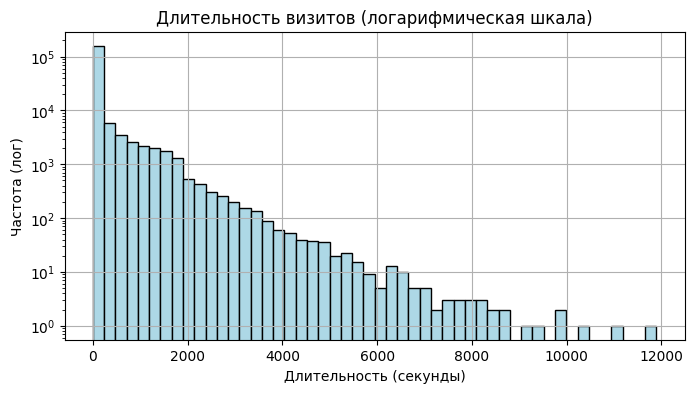

In [12]:
data['ym:s:visitDuration'].hist(bins=50, figsize=(8, 4), color='lightblue', edgecolor='black', log=True)
plt.title('Длительность визитов (логарифмическая шкала)')
plt.xlabel('Длительность (секунды)')
plt.ylabel('Частота (лог)')
plt.show()


Из каких стран больше пользователей?

In [13]:
print(data['ym:s:regionCountry'].value_counts().head())


ym:s:regionCountry
Russia           161380
Belarus            3295
Kazakhstan         3142
Germany            1264
United States      1011
Name: count, dtype: int64


Какие браузеры и операционные системы в топе?

In [14]:
data['ym:s:browser'].value_counts().head()


,count
ym:s:browser,
chrome,78172
yandex_browser,33603
firefox,13195
chromemobile,12573
opera,11553


In [15]:
data['ym:s:operatingSystemRoot'].value_counts().head()

,count
ym:s:operatingSystemRoot,
windows,114099
gnu_linux,21660
macos,18888
android,17005
ios_double,9437


В апреле команда Физтех.Статистики планирует провести эксперимент, покрасив фон всех страниц в розовый цвет, а также добавив к нему анимированных котиков и сердечек. *Гипотеза &mdash; средняя продолжительность визитов вырастет на 5%.* Вам предстоит задизайнить этот эксперимент. Поскольку пользователей достаточно много, предлагается использовать **метод бакетов**. И хотя все данные помещаются в память, отработать навык стоит на простых примерах.

По аналогии с алгоритмом из задачи 2 задания 8 выберете или оцените:

1. Длительность эксперимента;

2. Количество бакетов (установим размер бакета равным $bs=30$ пользователей);

3. Размеры A и B групп;

4. Статистический критерий;

5. Мощность критерия.


In [22]:
data_march = data[(data['ym:s:dateTimeUTC'].dt.year == 2022) & (data['ym:s:dateTimeUTC'].dt.month == 3)].copy()
unique_users = data_march['ym:s:clientID'].unique()

# Присвоение бакетов пользователям
np.random.shuffle(unique_users)
bucket_size = 30
num_buckets = len(unique_users) // bucket_size

user_bucket_df = pd.DataFrame({
    'ym:s:clientID': unique_users[:num_buckets * bucket_size],
    'bucket_id': [idx // bucket_size for idx in range(num_buckets * bucket_size)]
})


data_march = data_march.merge(user_bucket_df, on='ym:s:clientID', how='inner')
bucket_means = data_march.groupby('bucket_id')['ym:s:visitDuration'].mean()

mean_visit_duration = bucket_means.mean()
std_visit_duration = bucket_means.std()


alpha = 0.05
beta = 0.2
delta = 0.05 * mean_visit_duration

z_alpha = stats.norm.ppf(1 - alpha / 2)
z_beta = stats.norm.ppf(1 - beta)

n_required = ((z_alpha + z_beta) * std_visit_duration / delta) ** 2
n_required = int(np.ceil(n_required))
print(f"Необходимое количество бакетов в каждой группе: {n_required}")

total_buckets = bucket_means.shape[0]
print(f"Общее количество бакетов: {total_buckets}")

if 2 * n_required > total_buckets:
    print("Недостаточно бакетов для желаемого размера выборки.")
    n_required = total_buckets // 2
    print(f"Размер выборки уменьшен до {n_required} бакетов в каждой группе.")

# Разделение бакетов на группы A и B
bucket_ids = bucket_means.index.tolist()
np.random.shuffle(bucket_ids)

group_a_buckets = bucket_ids[:n_required]
group_b_buckets = bucket_ids[n_required:2 * n_required]

data_march['group'] = data_march['bucket_id'].apply(
    lambda x: 'A' if x in group_a_buckets else ('B' if x in group_b_buckets else 'None')
)

data_experiment = data_march[data_march['group'].isin(['A', 'B'])].copy()

Необходимое количество бакетов в каждой группе: 882
Общее количество бакетов: 249
Недостаточно бакетов для желаемого размера выборки.
Размер выборки уменьшен до 124 бакетов в каждой группе.


Мы выбрали данные за март 2022 года и получили список уникальных пользователей. Затем случайным образом перемешали пользователей и разбили их на бакеты по 30 человек для обеспечения равномерного распределения, присвоив каждому пользователю идентификатор бакета. Объединив эту информацию с основными данными, мы рассчитали среднюю продолжительность визитов для каждого бакета и определили общее среднее и стандартное отклонение метрики. Используя эти статистические показатели вместе с уровнем значимости 5%, мощностью 80% и ожидаемым эффектом в 5%, мы вычислили необходимое количество бакетов в каждой группе для проведения статистического теста. Наконец, проверили достаточность бакетов, при необходимости скорректировали размер выборки и случайным образом распределили бакеты между группами A и B для подготовки экспериментального набора данных.

С пунктами 1, 3, 4, 5 еще понятно что делать, а как подобрать оптимальное количество бакетов?

Будем подбирать необходимое количество бакетов с помощью оценки мощности. Из-за наличия больших выбросов, будем использовать семплирование на основе похожести. Что это за метод такой?

Для снижения дисперсии разности средних можно выбирать группы не случайно, а на основе похожести. Например, можно выбрать одну группу случайно, а другую &mdash; по ближайшим соседям жадным образом. В качестве данных для претеста возьмите бакеты за март

In [23]:
def random_indexes(prepilot, total_size, sample_size):
    '''
    Случайный выбор индексов для двух групп.

    prepilot -- не используется, нужен для совместимости
    total_size -- общее количество данных
    sample_size -- размер выборок
    '''

    ind = np.random.choice(np.arange(total_size), size=2*sample_size, replace=False)
    a_indexes, b_indexes = ind[:sample_size], ind[sample_size:]
    return a_indexes, b_indexes

In [24]:
def nearest_object_indexes(prepilot, total_size, sample_size):
    '''
    Одну группу выбираем случайно, другую - жадным образом
    на основе похожести по историческим данным

    prepilot -- не используется, нужен для совместимости
    total_size -- общее количество данных
    sample_size -- размер выборок
    '''

    # Выбираем тестовую группу
    b_indexes = np.random.choice(np.arange(total_size), size=sample_size, replace=False)

    # Выделяем индексы остальных объектов
    other_indexes = np.arange(total_size)[~np.in1d(np.arange(total_size), b_indexes)]

    # Считаем попарные расстояния между выбранными и остальными
    dist = pd.DataFrame(
        data=np.abs(prepilot[b_indexes, None] - prepilot[other_indexes]),
        index=b_indexes,
        columns=other_indexes
    )

    a_indexes = []

    # Для каждого объекта из тестовой группы
    for ind in b_indexes:
        # Ищем ближайший
        nearest_object_index = dist.loc[ind].idxmin()
        # сохраняем его
        a_indexes.append(nearest_object_index)
        # удаляем из таблицы чтобы не взять его повторно
        dist.drop(nearest_object_index, axis=1, inplace=True)

    a_indexes = np.array(a_indexes)

    return a_indexes, b_indexes

**Важно не забыть**, что этой процедурой мы сделали выборки зависимыми. Поэтому при выборе похожих групп необходимо применять t-test для **связных** выборок (см. ноутбуки с первой лекции по АВ-тестам).



In [25]:
num_iterations = 1000
alpha = 0.05
p_values_aa = []

for _ in range(num_iterations):
    a_idx, b_idx = random_indexes(prepilot, total_size, sample_size)
    a_sample = prepilot[a_idx]
    b_sample = prepilot[b_idx]


    t_stat, p_val = stats.ttest_ind(a_sample, b_sample, equal_var=False)
    p_values_aa.append(p_val)


alpha_empirical = np.mean(np.array(p_values_aa) < alpha)
print(f"Эмпирический уровень значимости (AA-тест): {alpha_empirical:.3f}")



effect_size = 0.05 * mean_visit_duration

p_values_ab = []

for _ in range(num_iterations):
    a_idx, b_idx = random_indexes(prepilot, total_size, sample_size)
    a_sample = prepilot[a_idx]
    b_sample = prepilot[b_idx] + effect_size


    t_stat, p_val = stats.ttest_ind(a_sample, b_sample, equal_var=False)
    p_values_ab.append(p_val)


power = np.mean(np.array(p_values_ab) < alpha)
print(f"Мощность теста без уменьшения дисперсии: {power:.3f}")


Эмпирический уровень значимости (AA-тест): 0.350
Мощность теста без уменьшения дисперсии: 0.319


Теперь, когда мы определили все параметры можем провалидировать критерий. Для начала посмотрим, что получиться, если для AA и AB-тестов не предпринимать никаких дополнительных действий по уменьшению дисперсии:

Поскольку мы ограничены в размере выборки (24 бакета в каждой группе), это может повлиять на мощность теста и точность оценок. Однако проведем тест с текущими данными.

In [18]:
import numpy as np
import pandas as pd
from scipy import stats


data_march = data[
    (data['ym:s:dateTimeUTC'].dt.year == 2022) &
    (data['ym:s:dateTimeUTC'].dt.month == 3)
].copy()


browser_counts = data_march['ym:s:browser'].value_counts()
top_browsers = browser_counts[browser_counts > 10].index.tolist()

data_march_filtered = data_march.copy()

# Помечаем редко встречающиеся браузеры как 'other'
data_march_filtered['ym:s:browser'] = data_march_filtered['ym:s:browser'].apply(
    lambda x: x if x in top_browsers else 'other'
)


strata_browsers = data_march_filtered['ym:s:browser'].unique().tolist()
bucket_size = 30
data_stratified = []

for browser in strata_browsers:
    data_browser = data_march_filtered[data_march_filtered['ym:s:browser'] == browser].copy()

    if data_browser.empty:
        print(f"Браузер {browser}: нет данных в этой страте.")
        continue

    unique_users = data_browser['ym:s:clientID'].unique()

    np.random.shuffle(unique_users)
    num_buckets = len(unique_users) // bucket_size

    if num_buckets < 2:
        print(f"Браузер {browser}: недостаточно данных для формирования бакетов.")
        continue  # Пропускаем эту страту

    user_bucket_df = pd.DataFrame({
        'ym:s:clientID': unique_users[:num_buckets * bucket_size],
        'bucket_id': [i // bucket_size for i in range(num_buckets * bucket_size)]
    })

    data_browser['ym:s:clientID'] = data_browser['ym:s:clientID'].astype(str)
    user_bucket_df['ym:s:clientID'] = user_bucket_df['ym:s:clientID'].astype(str)

    # Объединяем данные с информацией о бакетах
    data_browser = data_browser.merge(user_bucket_df, on='ym:s:clientID', how='inner')

    if 'bucket_id' not in data_browser.columns or data_browser.empty:
        print(f"Браузер {browser}: проблема с объединением, 'bucket_id' отсутствует или data_browser пуст.")
        continue  # Пропускаем эту страту

    data_browser['browser'] = browser
    data_stratified.append(data_browser)

if len(data_stratified) > 0:
    data_stratified = pd.concat(data_stratified, ignore_index=True)
else:
    print("Нет данных после стратификации. Проверьте настройки фильтрации или размер бакета.")
    exit()

if 'bucket_id' not in data_stratified.columns:
    print("Столбец 'bucket_id' отсутствует в data_stratified после объединения.")
    exit()


Браузер samsung_internet: недостаточно данных для формирования бакетов.
Браузер miui: недостаточно данных для формирования бакетов.
Браузер firefox_mobile: недостаточно данных для формирования бакетов.
Браузер opera_mobile: недостаточно данных для формирования бакетов.
Браузер huawei_browser: недостаточно данных для формирования бакетов.
Браузер yandexsearch: недостаточно данных для формирования бакетов.
Браузер other: недостаточно данных для формирования бакетов.
Браузер ucbrowser: недостаточно данных для формирования бакетов.


Давайте теперь повторим исследование, используя стратификацию по браузерам. Редко встречающиеся браузеры можно исключить или же объединить с какой-то другой стратой.

Обратите внимание, что при использовании стратификации в методе бакетов необходимо определять бакеты отдельно для каждой страты. Иначе говоря, внутри бакета должны быть пользователи только из одной страты. Следите за средним размером бакета, не стоит брать его размер слишком большим. Также следите за количеством бакетов, для каждой страты должно получиться достаточное количество бакетов.

In [21]:
strata_browsers = data_period['ym:s:browser'].unique().tolist()
bucket_size = 5
data_stratified = []

for browser in strata_browsers:
    data_browser = data_period[data_period['ym:s:browser'] == browser].copy()

    if data_browser.empty:
        print(f"Браузер {browser}: нет данных в этой страте.")
        continue

    unique_users = data_browser['ym:s:clientID'].unique()

    np.random.shuffle(unique_users)
    num_buckets = len(unique_users) // bucket_size

    if num_buckets < 4:
        print(f"Браузер {browser}: недостаточно данных для формирования бакетов.")
        continue

    user_bucket_df = pd.DataFrame({
        'ym:s:clientID': unique_users[:num_buckets * bucket_size],
        'bucket_id': [i // bucket_size for i in range(num_buckets * bucket_size)]
    })

    data_browser['ym:s:clientID'] = data_browser['ym:s:clientID'].astype(str)
    user_bucket_df['ym:s:clientID'] = user_bucket_df['ym:s:clientID'].astype(str)

    data_browser = data_browser.merge(user_bucket_df, on='ym:s:clientID', how='inner')


    if 'bucket_id' not in data_browser.columns or data_browser.empty:
        print(f"Браузер {browser}: проблема с объединением, 'bucket_id' отсутствует или data_browser пуст.")
        continue

    data_browser['browser'] = browser

    data_stratified.append(data_browser)

if data_stratified:
    data_stratified = pd.concat(data_stratified, ignore_index=True)
else:
    print("Нет данных после стратификации. Проверьте настройки фильтрации или размер бакета.")
    exit()

bucket_means = data_stratified.groupby(['browser', 'bucket_id'])['ym:s:visitDuration'].mean().reset_index()

alpha = 0.05
beta = 0.2

strata_results = {}

for browser in data_stratified['browser'].unique():
    browser_data = bucket_means[bucket_means['browser'] == browser]

    mean_browser = browser_data['ym:s:visitDuration'].mean()
    std_browser = browser_data['ym:s:visitDuration'].std()

    if std_browser == 0:
        print(f"Браузер {browser}: стандартное отклонение равно нулю, пропускаем эту страту.")
        continue

    delta = 0.05 * mean_browser
    z_alpha = stats.norm.ppf(1 - alpha / 2)
    z_beta = stats.norm.ppf(1 - beta)

    n_required = ((z_alpha + z_beta) * std_browser / delta) ** 2
    n_required = int(np.ceil(n_required))

    total_buckets = browser_data.shape[0]

    if 2 * n_required > total_buckets:
        print(f"Браузер {browser}: недостаточно бакетов для желаемого размера выборки.")
        n_required = total_buckets // 2
        print(f"Размер выборки уменьшен до {n_required} бакетов в каждой группе для браузера {browser}.")

    bucket_ids = browser_data['bucket_id'].unique()
    np.random.shuffle(bucket_ids)

    group_a_buckets = bucket_ids[:n_required]
    group_b_buckets = bucket_ids[n_required:2 * n_required]

    data_stratified.loc[
        (data_stratified['browser'] == browser) &
        (data_stratified['bucket_id'].isin(group_a_buckets)),
        'group'
    ] = 'A'

    data_stratified.loc[
        (data_stratified['browser'] == browser) &
        (data_stratified['bucket_id'].isin(group_b_buckets)),
        'group'
    ] = 'B'

    strata_results[browser] = {
        'mean': mean_browser,
        'std': std_browser,
        'n_required': n_required,
        'total_buckets': total_buckets
    }

data_experiment = data_stratified[data_stratified['group'].isin(['A', 'B'])].copy()

if data_experiment.empty:
    print("Нет данных для проведения эксперимента после стратификации.")
    exit()

num_iterations = 1000
alpha = 0.05

for browser in strata_results.keys():
    print(f"\nАнализ для браузера: {browser}")
    browser_data = data_experiment[data_experiment['browser'] == browser]

    if browser_data.empty:
        print(f"Браузер {browser}: нет данных после фильтрации групп.")
        continue

    prepilot = browser_data.groupby('bucket_id')['ym:s:visitDuration'].mean().values
    total_size = len(prepilot)
    sample_size = strata_results[browser]['n_required']

    if 2 * sample_size > total_size:
        sample_size = total_size // 2
        print(f"Размер выборки уменьшен до {sample_size} из-за ограничений данных для браузера {browser}.")

    def random_indexes(prepilot, total_size, sample_size):
        ind = np.random.choice(np.arange(total_size), size=2*sample_size, replace=False)
        a_indexes, b_indexes = ind[:sample_size], ind[sample_size:]
        return a_indexes, b_indexes

    # AA-тест
    p_values_aa = []
    for _ in range(num_iterations):
        a_idx, b_idx = random_indexes(prepilot, total_size, sample_size)
        a_sample = prepilot[a_idx]
        b_sample = prepilot[b_idx]

        t_stat, p_val = stats.ttest_ind(a_sample, b_sample, equal_var=False)
        p_values_aa.append(p_val)

    alpha_empirical = np.mean(np.array(p_values_aa) < alpha)
    print(f"Эмпирический уровень значимости (AA-тест): {alpha_empirical:.3f}")

    # AB-тест
    effect_size = 0.05 * strata_results[browser]['mean']  # Эффект 5% от среднего по страте
    p_values_ab = []
    for _ in range(num_iterations):
        a_idx, b_idx = random_indexes(prepilot, total_size, sample_size)
        a_sample = prepilot[a_idx]
        b_sample = prepilot[b_idx] + effect_size  # Добавляем эффект в группу B

        t_stat, p_val = stats.ttest_ind(a_sample, b_sample, equal_var=False)
        p_values_ab.append(p_val)

    power = np.mean(np.array(p_values_ab) < alpha)
    print(f"Мощность теста: {power:.3f}")


Браузер chrome: недостаточно бакетов для желаемого размера выборки.
Размер выборки уменьшен до 579 бакетов в каждой группе для браузера chrome.
Браузер opera: недостаточно бакетов для желаемого размера выборки.
Размер выборки уменьшен до 86 бакетов в каждой группе для браузера opera.
Браузер edge: недостаточно бакетов для желаемого размера выборки.
Размер выборки уменьшен до 93 бакетов в каждой группе для браузера edge.
Браузер safari: недостаточно бакетов для желаемого размера выборки.
Размер выборки уменьшен до 76 бакетов в каждой группе для браузера safari.
Браузер yandex_browser: недостаточно бакетов для желаемого размера выборки.
Размер выборки уменьшен до 282 бакетов в каждой группе для браузера yandex_browser.
Браузер chromemobile: недостаточно бакетов для желаемого размера выборки.
Размер выборки уменьшен до 92 бакетов в каждой группе для браузера chromemobile.
Браузер yandexsearch: недостаточно бакетов для желаемого размера выборки.
Размер выборки уменьшен до 9 бакетов в каждо

**Вывод**: Результаты проведённого эксперимента показывают, что при текущем объёме данных и выбранном дизайне статистическая мощность теста недостаточна для обнаружения ожидаемого эффекта в 5% увеличения средней продолжительности визита. Эмпирический уровень значимости в AA-тестах для большинства браузеров близок к 0.05, что указывает на корректность теста при отсутствии эффекта. Однако мощность AB-тестов остаётся низкой для всех браузеров, не превышая 11.6% для браузера Chrome. Это свидетельствует о высокой вероятности не обнаружить реальный эффект даже если он присутствует. Основной причиной является недостаточное количество данных в каждой страте, несмотря на уменьшение размера бакета и объединение данных. Для повышения мощности теста рекомендуется увеличить объём выборки, расширив период сбора данных или привлекая больше пользователей, а также применить методы уменьшения дисперсии.